# Ensemble Techniques and Class Imbalance
## Comprehensive Lab Exercise: 5 Scenarios



In [1]:
import warnings
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Name: Mohamed Aashik S \nRoll No: 24BAD072\n")



Name: Mohamed Aashik S 
Roll No: 24BAD072



---
# SCENARIO 1 - BAGGING: Diabetes Prediction


In [85]:
diabetes_df = pd.read_csv('Data set/diabetes_bagging.csv')



In [86]:
X_diabetes = diabetes_df.drop('Outcome', axis=1)
y_diabetes = diabetes_df['Outcome']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)



In [87]:

dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_classifier.fit(X_train_d, y_train_d)
dt_pred = dt_classifier.predict(X_test_d)

dt_accuracy = accuracy_score(y_test_d, dt_pred)
dt_precision = precision_score(y_test_d, dt_pred)
dt_recall = recall_score(y_test_d, dt_pred)
dt_f1 = f1_score(y_test_d, dt_pred)



In [88]:

bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

bagging_classifier.fit(X_train_d, y_train_d)
bagging_pred = bagging_classifier.predict(X_test_d)

bagging_accuracy = accuracy_score(y_test_d, bagging_pred)
bagging_precision = precision_score(y_test_d, bagging_pred)
bagging_recall = recall_score(y_test_d, bagging_pred)
bagging_f1 = f1_score(y_test_d, bagging_pred)



In [89]:
scenario1_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging'],
    'Accuracy': [dt_accuracy, bagging_accuracy],
    'Precision': [dt_precision, bagging_precision],
    'Recall': [dt_recall, bagging_recall],
    'F1-Score': [dt_f1, bagging_f1]
})

scenario1_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.958333,1.0,0.933333,0.965517
1,Bagging,0.958333,1.0,0.933333,0.965517


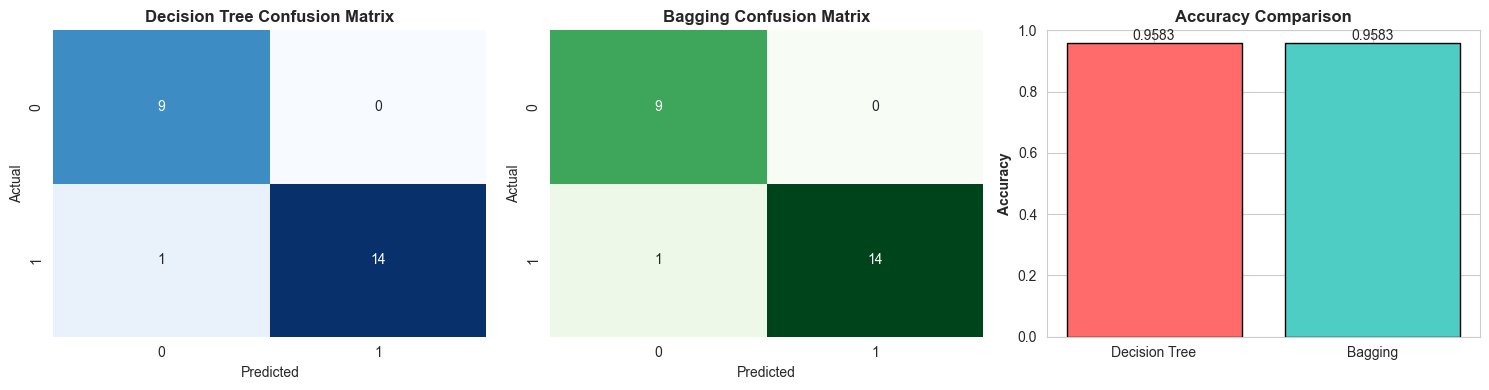

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_dt = confusion_matrix(y_test_d, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Decision Tree Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_bagging = confusion_matrix(y_test_d, bagging_pred)
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Bagging Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

models_s1 = ['Decision Tree', 'Bagging']
accuracies_s1 = [dt_accuracy, bagging_accuracy]
bars = axes[2].bar(models_s1, accuracies_s1, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[2].set_ylabel('Accuracy', fontweight='bold')
axes[2].set_title('Accuracy Comparison', fontweight='bold')
axes[2].set_ylim([0, 1])
for bar, acc in zip(bars, accuracies_s1):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{acc:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

---
# SCENARIO 2 - BOOSTING: Customer Churn Prediction


In [91]:
churn_df = pd.read_csv('Data set/churn_boosting.csv')



In [92]:
target_col = 'Churn' if 'Churn' in churn_df.columns else churn_df.columns[-1]

if churn_df[target_col].dtype == 'object':
    le_target = LabelEncoder()
    y_churn = le_target.fit_transform(churn_df[target_col])
else:
    y_churn = churn_df[target_col]

id_cols = [col for col in churn_df.columns if col.lower() in ['id', 'customerid', 'customer id']]
feature_cols = [col for col in churn_df.columns if col not in id_cols and col != target_col]
X_churn_raw = churn_df[feature_cols].copy()

for col in X_churn_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_churn_raw[col] = le.fit_transform(X_churn_raw[col].astype(str))

X_churn = X_churn_raw

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)



In [93]:

adaboost_classifier = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

adaboost_classifier.fit(X_train_c, y_train_c)
adaboost_pred = adaboost_classifier.predict(X_test_c)
adaboost_pred_proba = adaboost_classifier.predict_proba(X_test_c)[:, 1]

ada_accuracy = accuracy_score(y_test_c, adaboost_pred)
ada_precision = precision_score(y_test_c, adaboost_pred)
ada_recall = recall_score(y_test_c, adaboost_pred)
ada_f1 = f1_score(y_test_c, adaboost_pred)
ada_auc = roc_auc_score(y_test_c, adaboost_pred_proba)



In [94]:

gb_classifier = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_classifier.fit(X_train_c, y_train_c)
gb_pred = gb_classifier.predict(X_test_c)
gb_pred_proba = gb_classifier.predict_proba(X_test_c)[:, 1]

gb_accuracy = accuracy_score(y_test_c, gb_pred)
gb_precision = precision_score(y_test_c, gb_pred)
gb_recall = recall_score(y_test_c, gb_pred)
gb_f1 = f1_score(y_test_c, gb_pred)
gb_auc = roc_auc_score(y_test_c, gb_pred_proba)



In [95]:
scenario2_comparison = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting'],
    'Accuracy': [ada_accuracy, gb_accuracy],
    'Precision': [ada_precision, gb_precision],
    'Recall': [ada_recall, gb_recall],
    'F1-Score': [ada_f1, gb_f1],
    'AUC-ROC': [ada_auc, gb_auc]
})

scenario2_comparison

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,AdaBoost,1.0,1.0,1.0,1.0,1.0
1,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


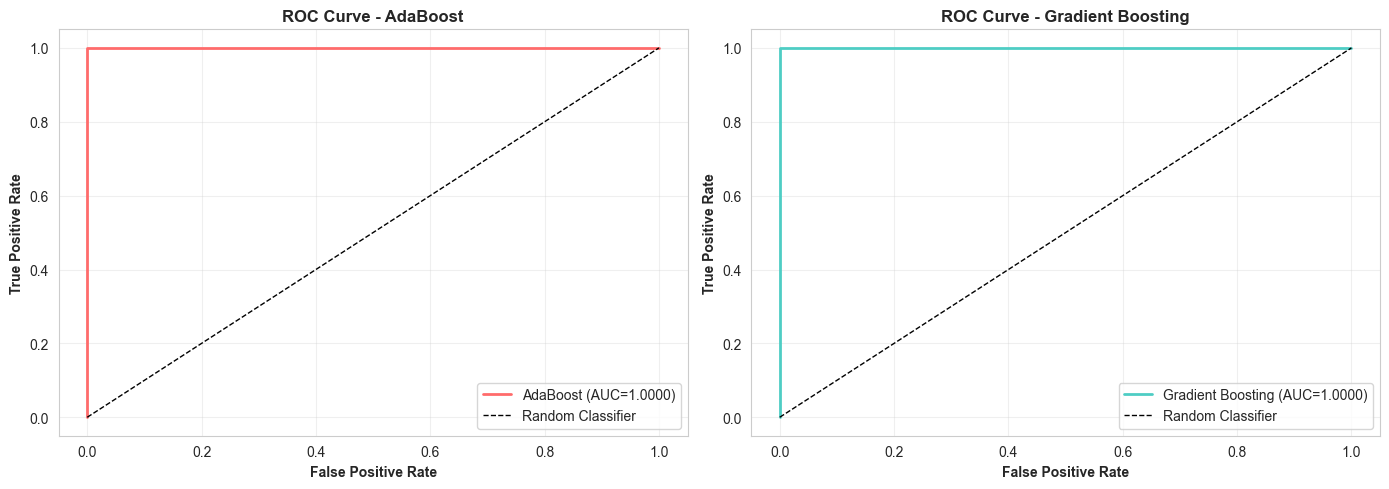

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_ada, tpr_ada, _ = roc_curve(y_test_c, adaboost_pred_proba)
axes[0].plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC={ada_auc:.4f})', linewidth=2, color='#FF6B6B')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve - AdaBoost', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

fpr_gb, tpr_gb, _ = roc_curve(y_test_c, gb_pred_proba)
axes[1].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={gb_auc:.4f})', linewidth=2, color='#4ECDC4')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve - Gradient Boosting', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



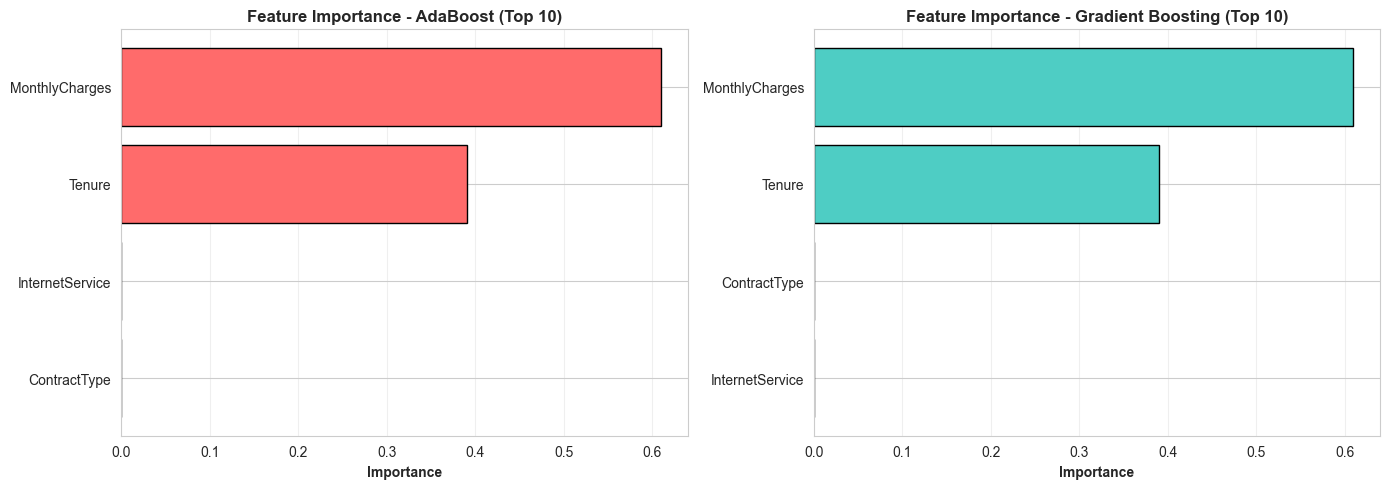

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ada_importance = adaboost_classifier.feature_importances_
ada_importance_sorted = np.argsort(ada_importance)[-10:]  # Top 10
top_features_ada = [X_train_c.columns[i] for i in ada_importance_sorted]
top_importance_ada = ada_importance[ada_importance_sorted]

axes[0].barh(range(len(top_features_ada)), top_importance_ada, color='#FF6B6B', edgecolor='black')
axes[0].set_yticks(range(len(top_features_ada)))
axes[0].set_yticklabels(top_features_ada)
axes[0].set_xlabel('Importance', fontweight='bold')
axes[0].set_title('Feature Importance - AdaBoost (Top 10)', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

gb_importance = gb_classifier.feature_importances_
gb_importance_sorted = np.argsort(gb_importance)[-10:]  # Top 10
top_features_gb = [X_train_c.columns[i] for i in gb_importance_sorted]
top_importance_gb = gb_importance[gb_importance_sorted]

axes[1].barh(range(len(top_features_gb)), top_importance_gb, color='#4ECDC4', edgecolor='black')
axes[1].set_yticks(range(len(top_features_gb)))
axes[1].set_yticklabels(top_features_gb)
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('Feature Importance - Gradient Boosting (Top 10)', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



---
# SCENARIO 3 - RANDOM FOREST: Income Prediction (>50K)


In [98]:
income_df = pd.read_csv('Data set/income_random_forest.csv')



In [99]:
target_col_income = 'Income' if 'Income' in income_df.columns else income_df.columns[-1]

if income_df[target_col_income].dtype == 'object':
    le_income = LabelEncoder()
    y_income = le_income.fit_transform(income_df[target_col_income].astype(str))
else:
    y_income = income_df[target_col_income]

id_cols_income = [col for col in income_df.columns if col.lower() in ['id', 'customerid', 'customer id']]
feature_cols_income = [col for col in income_df.columns if col not in id_cols_income and col != target_col_income]
X_income_raw = income_df[feature_cols_income].copy()

for col in X_income_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_income_raw[col] = le.fit_transform(X_income_raw[col].astype(str))

X_income = X_income_raw

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_income, y_income, test_size=0.2, random_state=42, stratify=y_income
)



In [100]:
n_trees_list = [10, 50, 100, 200]
rf_models = {}
rf_accuracies = {}
rf_f1_scores = {}

for n_trees in n_trees_list:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_i, y_train_i)
    rf_pred = rf.predict(X_test_i)
    rf_models[n_trees] = rf
    rf_accuracies[n_trees] = accuracy_score(y_test_i, rf_pred)
    rf_f1_scores[n_trees] = f1_score(y_test_i, rf_pred)

best_n_trees = max(rf_accuracies, key=rf_accuracies.get)
best_rf = rf_models[best_n_trees]
best_rf_accuracy = rf_accuracies[best_n_trees]
best_rf_f1 = rf_f1_scores[best_n_trees]

scenario3_comparison = pd.DataFrame({
    'n_estimators': n_trees_list,
    'Accuracy': [rf_accuracies[n] for n in n_trees_list],
    'F1-Score': [rf_f1_scores[n] for n in n_trees_list]
})

scenario3_comparison

,n_estimators,Accuracy,F1-Score
0,10,1.0,1.0
1,50,1.0,1.0
2,100,1.0,1.0
3,200,1.0,1.0


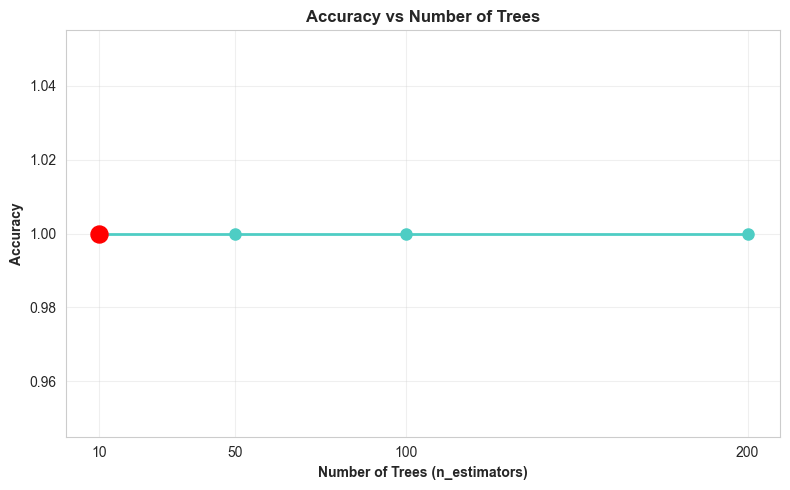

In [101]:
plt.figure(figsize=(8, 5))
plt.plot(
    n_trees_list,
    [rf_accuracies[n] for n in n_trees_list],
    marker='o',
    linewidth=2,
    markersize=8,
    color='#4ECDC4'
)
plt.scatter(best_n_trees, best_rf_accuracy, s=150, color='red', zorder=5)
plt.xlabel('Number of Trees (n_estimators)', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Accuracy vs Number of Trees', fontweight='bold')
plt.xticks(n_trees_list)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

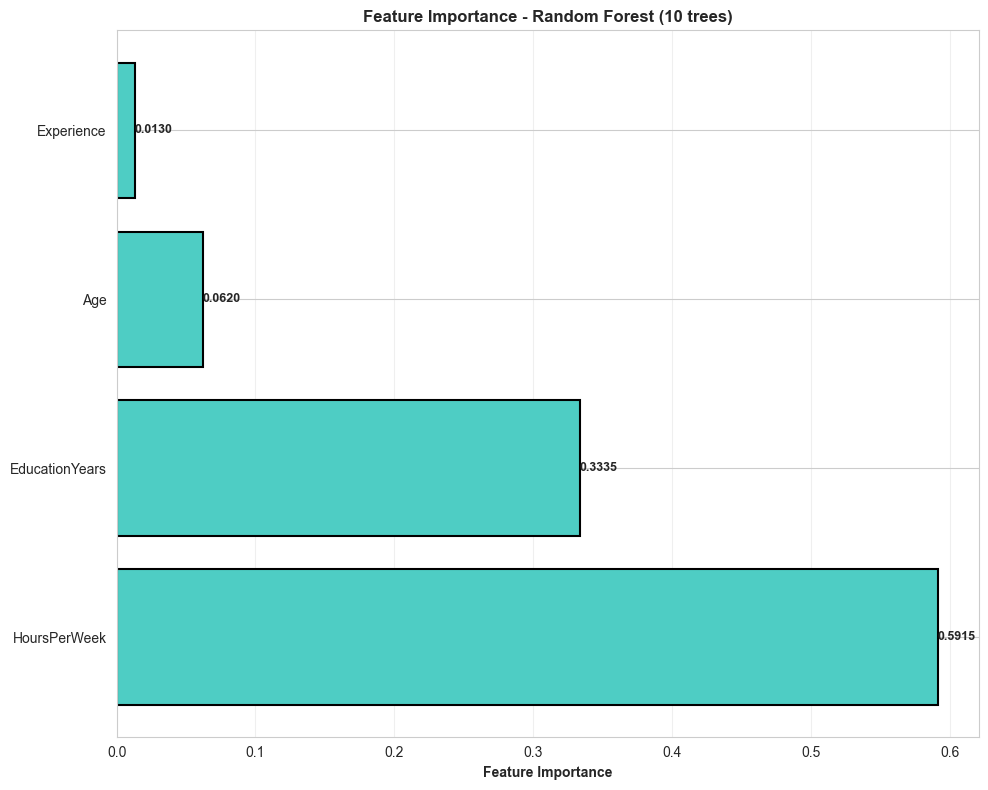

In [102]:
feature_importance = best_rf.feature_importances_
feature_names = X_train_i.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(importance_df)), importance_df['Importance'].values, 
                color='#4ECDC4', edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['Feature'].values)
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title(f'Feature Importance - Random Forest ({best_n_trees} trees)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'{width:.4f}',
           ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()



---
# SCENARIO 4 - STACKING: Heart Disease Detection


In [103]:
heart_df = pd.read_csv('Data set/heart_stacking.csv')



In [104]:
target_col_heart = 'target' if 'target' in heart_df.columns else heart_df.columns[-1]

if heart_df[target_col_heart].dtype == 'object':
    le_heart = LabelEncoder()
    y_heart = le_heart.fit_transform(heart_df[target_col_heart].astype(str))
else:
    y_heart = heart_df[target_col_heart]

id_cols_heart = [col for col in heart_df.columns if col.lower() in ['id', 'customerid', 'patient id']]
feature_cols_heart = [col for col in heart_df.columns if col not in id_cols_heart and col != target_col_heart]
X_heart_raw = heart_df[feature_cols_heart].copy()

for col in X_heart_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_heart_raw[col] = le.fit_transform(X_heart_raw[col].astype(str))

X_heart = X_heart_raw

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)



In [105]:

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_h, y_train_h)
lr_pred = lr_model.predict(X_test_h)
lr_accuracy = accuracy_score(y_test_h, lr_pred)
lr_f1 = f1_score(y_test_h, lr_pred)


svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_h, y_train_h)
svm_pred = svm_model.predict(X_test_h)
svm_accuracy = accuracy_score(y_test_h, svm_pred)
svm_f1 = f1_score(y_test_h, svm_pred)


dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_h, y_train_h)
dt_pred = dt_model.predict(X_test_h)
dt_accuracy = accuracy_score(y_test_h, dt_pred)
dt_f1 = f1_score(y_test_h, dt_pred)



In [106]:

base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stacking_classifier = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

stacking_classifier.fit(X_train_h, y_train_h)
stacking_pred = stacking_classifier.predict(X_test_h)

stacking_accuracy = accuracy_score(y_test_h, stacking_pred)
stacking_precision = precision_score(y_test_h, stacking_pred)
stacking_recall = recall_score(y_test_h, stacking_pred)
stacking_f1 = f1_score(y_test_h, stacking_pred)



In [107]:
scenario4_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking Classifier'],
    'Accuracy': [lr_accuracy, svm_accuracy, dt_accuracy, stacking_accuracy],
    'Precision': [
        precision_score(y_test_h, lr_pred),
        precision_score(y_test_h, svm_pred),
        precision_score(y_test_h, dt_pred),
        stacking_precision
    ],
    'Recall': [
        recall_score(y_test_h, lr_pred),
        recall_score(y_test_h, svm_pred),
        recall_score(y_test_h, dt_pred),
        stacking_recall
    ],
    'F1-Score': [lr_f1, svm_f1, dt_f1, stacking_f1]
})

scenario4_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.791667,0.875000,0.823529,0.848485
1,SVM,0.875000,0.888889,0.941176,0.914286
2,Decision Tree,1.000000,1.000000,1.000000,1.000000
3,Stacking Classifier,1.000000,1.000000,1.000000,1.000000


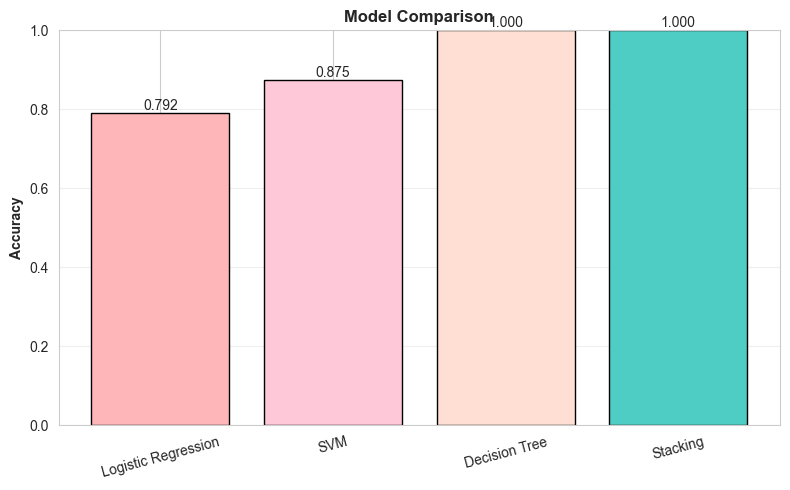

In [108]:
plt.figure(figsize=(8, 5))
models_s4 = ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking']
accuracies_s4 = scenario4_comparison['Accuracy'].values
bars = plt.bar(models_s4, accuracies_s4, color=['#FFB6B9', '#FEC8D8', '#FFDFD3', '#4ECDC4'], edgecolor='black')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Model Comparison', fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=15)
for bar, score in zip(bars, accuracies_s4):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{score:.3f}', ha='center', va='bottom')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
# SCENARIO 5 - SMOTE: Fraud Detection with Class Imbalance


In [109]:
fraud_df = pd.read_csv('Data set/fraud_smote.csv')



In [110]:
target_col_fraud = 'fraud' if 'fraud' in fraud_df.columns else fraud_df.columns[-1]
if 'Fraud' in fraud_df.columns:
    target_col_fraud = 'Fraud'

if fraud_df[target_col_fraud].dtype == 'object':
    le_fraud = LabelEncoder()
    y_fraud = le_fraud.fit_transform(fraud_df[target_col_fraud].astype(str))
else:
    y_fraud = fraud_df[target_col_fraud].values

id_cols_fraud = [col for col in fraud_df.columns if col.lower() in ['id', 'transactionid', 'transaction id']]
feature_cols_fraud = [col for col in fraud_df.columns if col not in id_cols_fraud and col != target_col_fraud]
X_fraud_raw = fraud_df[feature_cols_fraud].copy()

for col in X_fraud_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_fraud_raw[col] = le.fit_transform(X_fraud_raw[col].astype(str))

X_fraud = X_fraud_raw

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)



In [111]:

model_without_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_without_smote.fit(X_train_f, y_train_f)
pred_without_smote = model_without_smote.predict(X_test_f)
pred_proba_without_smote = model_without_smote.predict_proba(X_test_f)[:, 1]

without_smote_accuracy = accuracy_score(y_test_f, pred_without_smote)
without_smote_precision = precision_score(y_test_f, pred_without_smote, zero_division=0)
without_smote_recall = recall_score(y_test_f, pred_without_smote, zero_division=0)
without_smote_f1 = f1_score(y_test_f, pred_without_smote, zero_division=0)



In [112]:

smote = SMOTE(random_state=42)
X_train_f_smote, y_train_f_smote = smote.fit_resample(X_train_f, y_train_f)



In [113]:

model_with_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_with_smote.fit(X_train_f_smote, y_train_f_smote)
pred_with_smote = model_with_smote.predict(X_test_f)
pred_proba_with_smote = model_with_smote.predict_proba(X_test_f)[:, 1]

with_smote_accuracy = accuracy_score(y_test_f, pred_with_smote)
with_smote_precision = precision_score(y_test_f, pred_with_smote, zero_division=0)
with_smote_recall = recall_score(y_test_f, pred_with_smote, zero_division=0)
with_smote_f1 = f1_score(y_test_f, pred_with_smote, zero_division=0)



In [114]:
scenario5_comparison = pd.DataFrame({
    'Model': ['Without SMOTE', 'With SMOTE'],
    'Accuracy': [without_smote_accuracy, with_smote_accuracy],
    'Precision': [without_smote_precision, with_smote_precision],
    'Recall': [without_smote_recall, with_smote_recall],
    'F1-Score': [without_smote_f1, with_smote_f1]
})

scenario5_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Without SMOTE,0.916667,0.0,0.0,0.0
1,With SMOTE,0.833333,0.0,0.0,0.0


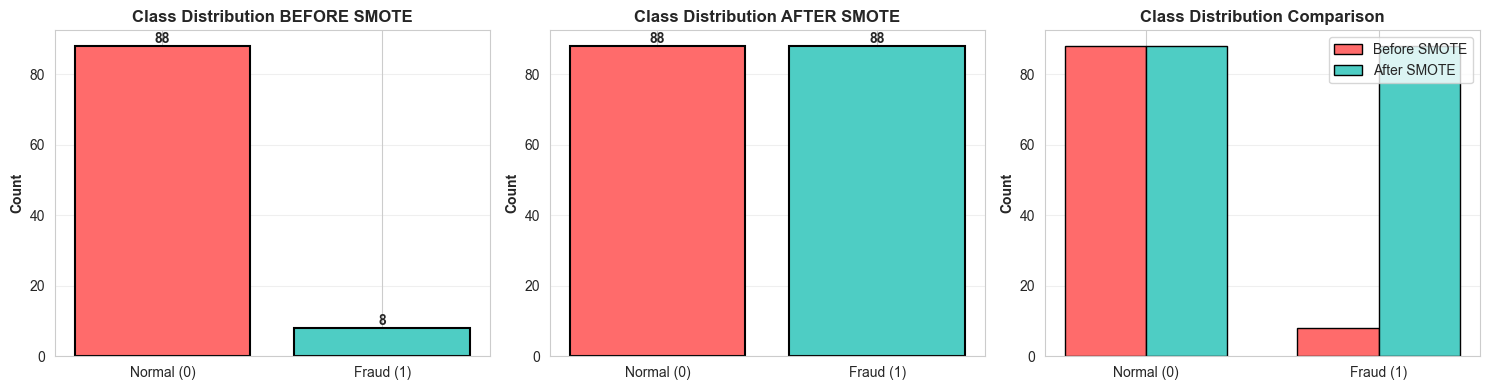

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_counts_before = pd.Series(y_train_f).value_counts().sort_index()
colors_class = ['#FF6B6B', '#4ECDC4']
axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts_before.values, color=colors_class, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Class Distribution BEFORE SMOTE', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(class_counts_before.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

class_counts_after = pd.Series(y_train_f_smote).value_counts().sort_index()
axes[1].bar(['Normal (0)', 'Fraud (1)'], class_counts_after.values, color=colors_class, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Class Distribution AFTER SMOTE', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(class_counts_after.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, class_counts_before.values, width, label='Before SMOTE', color='#FF6B6B', edgecolor='black')
axes[2].bar(x + width/2, class_counts_after.values, width, label='After SMOTE', color='#4ECDC4', edgecolor='black')
axes[2].set_ylabel('Count', fontweight='bold')
axes[2].set_title('Class Distribution Comparison', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Normal (0)', 'Fraud (1)'])
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



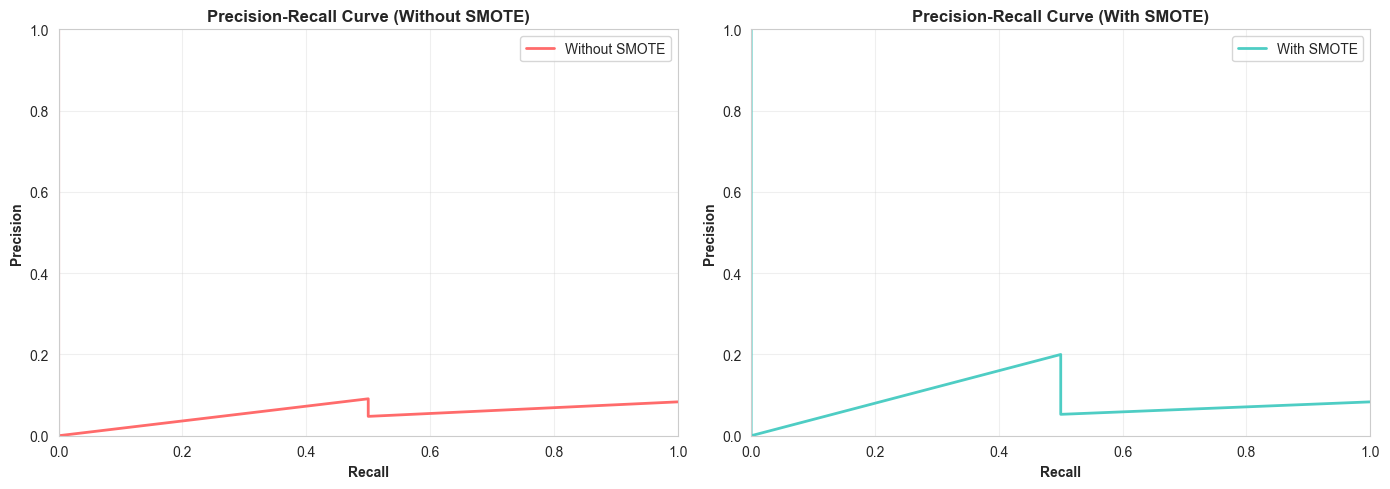

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

precision_without, recall_without, _ = precision_recall_curve(y_test_f, pred_proba_without_smote)
axes[0].plot(recall_without, precision_without, linewidth=2, color='#FF6B6B', label='Without SMOTE')
axes[0].set_xlabel('Recall', fontweight='bold')
axes[0].set_ylabel('Precision', fontweight='bold')
axes[0].set_title('Precision-Recall Curve (Without SMOTE)', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

precision_with, recall_with, _ = precision_recall_curve(y_test_f, pred_proba_with_smote)
axes[1].plot(recall_with, precision_with, linewidth=2, color='#4ECDC4', label='With SMOTE')
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Curve (With SMOTE)', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

